Using final-results workbook: D:\Headway\final run\tables\T6_Final_AFT_Bootstrap_CoxSnell.xlsx

Refit audit:
                Pair      Distribution  Reported logLik  Refitted logLik  Absolute difference
    BTW_following_4W Generalized gamma      -276.443102      -276.443102                  0.0
 BTW_following_MT_3W  Inverse Gaussian      -186.730248      -186.730248                  0.0
BTW_following_NMT_3W             Gamma      -143.955713      -143.955713                  0.0
 BTW_following_MT_2W             Gamma       -75.323137       -75.323137                  0.0
BTW_following_NMT_2W  Inverse Gaussian       -40.242033       -40.242033                  0.0
     PR_following_4W Generalized gamma       -62.216366       -62.216366                  0.0
  PR_following_MT_3W           Weibull      -128.283918      -128.283918                  0.0


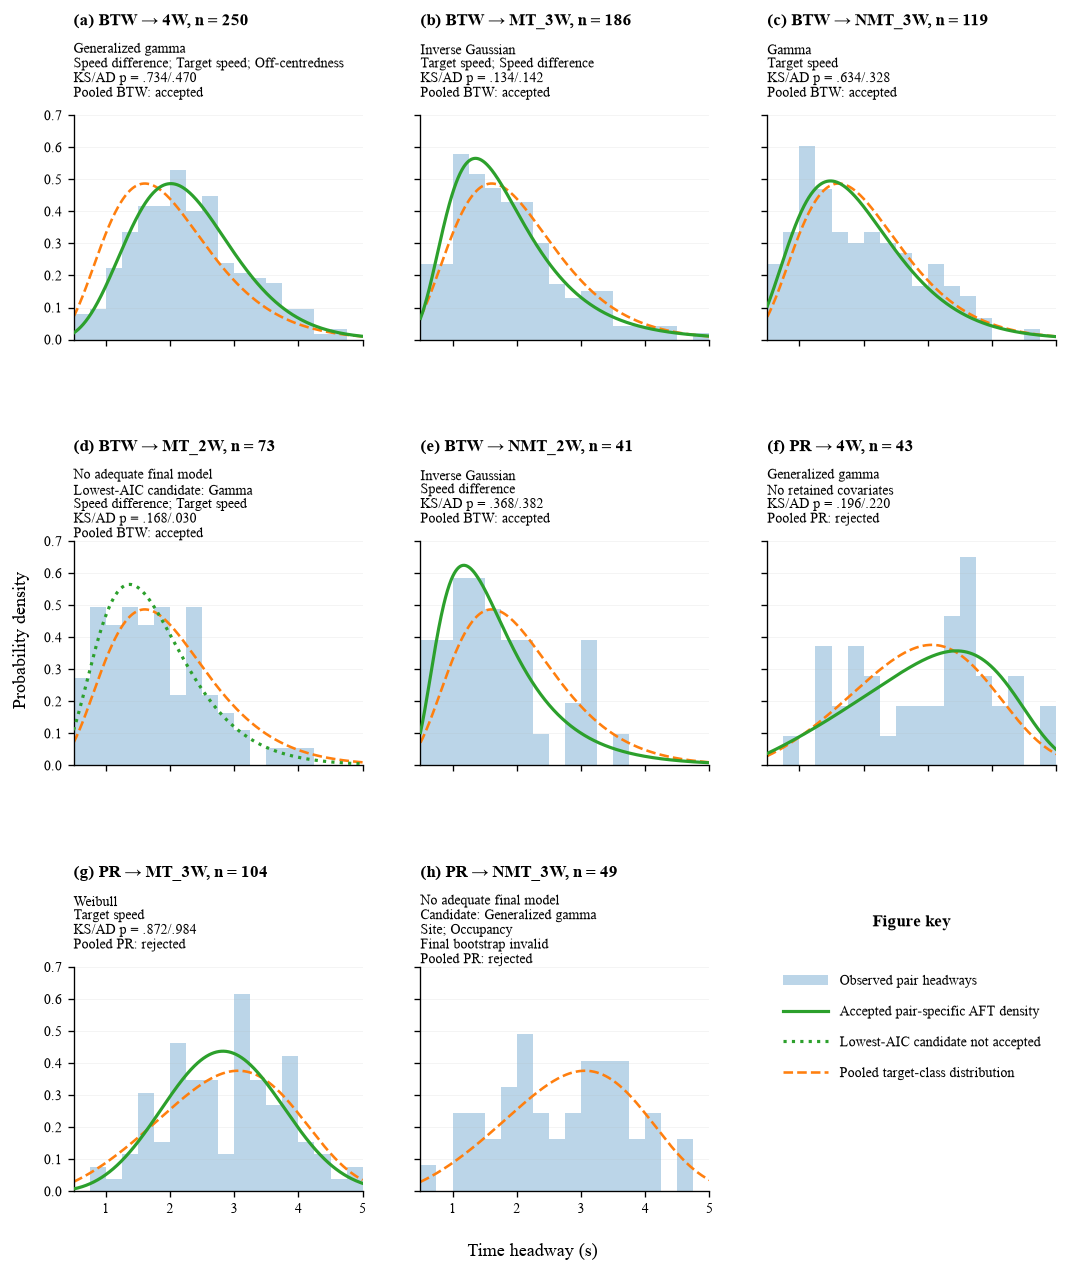


Saved final density figure:
D:\Headway\Graphics\F_Final_pairwise_AFT_vs_pooled_3x3.png
D:\Headway\Graphics\F_Final_pairwise_AFT_vs_pooled_3x3.pdf


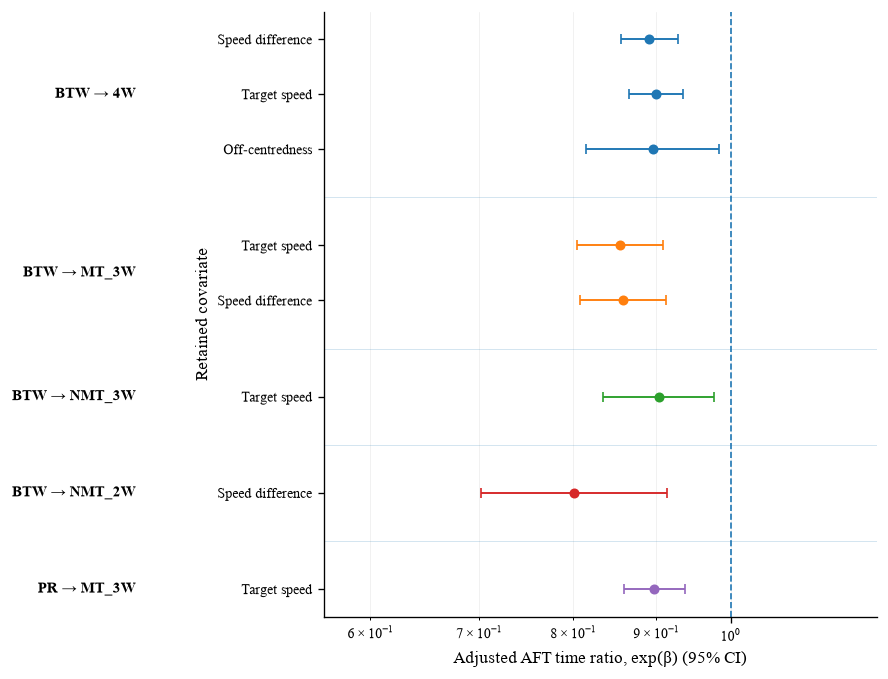


Saved AFT forest plot and coefficient table:
D:\Headway\Graphics\F_AFT_adjusted_time_ratios_forest.png
D:\Headway\Graphics\F_AFT_adjusted_time_ratios_forest.pdf
D:\Headway\Tables\Final_AFT_time_ratios_95CI.csv
D:\Headway\Tables\Final_AFT_Hessian_audit.csv


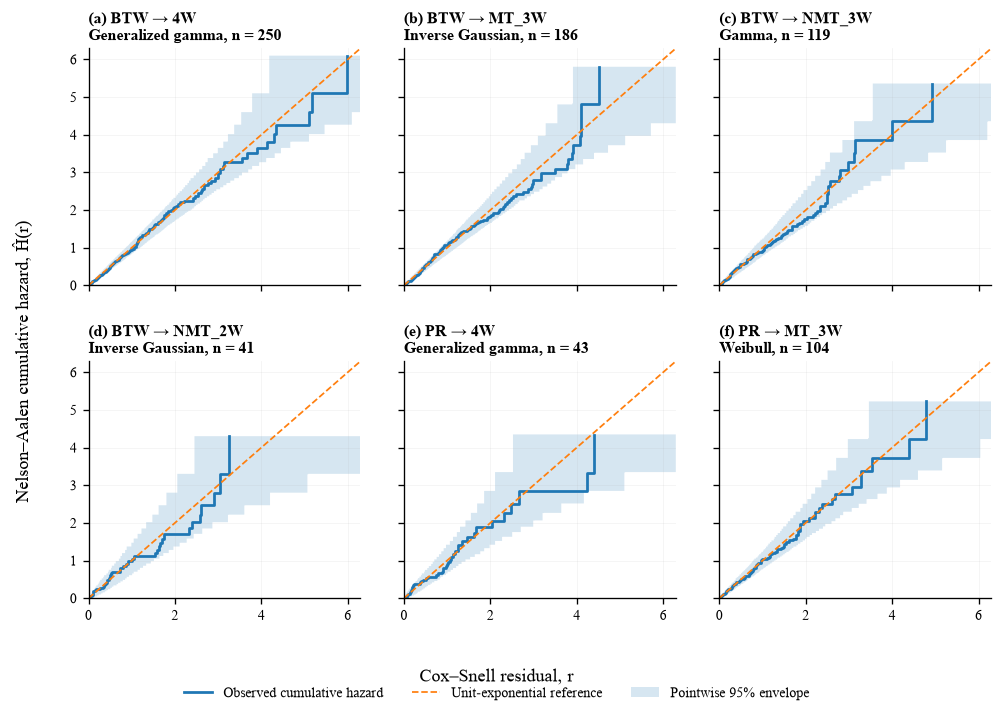


Saved Cox–Snell verification figure and metrics:
D:\Headway\Graphics\F_CoxSnell_final_adequate_models.png
D:\Headway\Graphics\F_CoxSnell_final_adequate_models.pdf
D:\Headway\Tables\Final_CoxSnell_residual_metrics.csv

All final figures completed successfully.


In [1]:
# =============================================================================
# FINAL FIGURE:
# Observed pair-specific histogram versus final AFT density and pooled reference
# =============================================================================

import os
import glob
import zlib
import warnings

import numpy as np
import pandas as pd
from scipy import stats, optimize

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from statsmodels.tools.numdiff import approx_hess

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------------
# 1. Paths
# -------------------------------------------------------------------------
BASE = r"D:\Headway"
DATA = os.path.join(BASE, "data3.xlsx")
TABLES = os.path.join(BASE, "Tables")
GRAPHS = os.path.join(BASE, "Graphics")

os.makedirs(GRAPHS, exist_ok=True)

# Set an explicit path here when preferred.
# When left as None, the code searches TABLES for the workbook containing
# the final S3, S5 and S8 result sheets.
RESULTS = r"D:\Headway\final run\tables\T6_Final_AFT_Bootstrap_CoxSnell.xlsx"

REQUIRED_SHEETS = {
    "S3_AFT_final_GOF",
    "S5_Final_decisions",
    "S8_Pooled_GOF",
}


def find_results_workbook(folder):
    candidates = sorted(
        glob.glob(os.path.join(folder, "*.xlsx")),
        key=os.path.getmtime,
        reverse=True,
    )

    for path in candidates:
        try:
            sheets = set(pd.ExcelFile(path).sheet_names)
            if REQUIRED_SHEETS.issubset(sheets):
                return path
        except Exception:
            continue

    raise FileNotFoundError(
        "No workbook containing S3_AFT_final_GOF, "
        "S5_Final_decisions and S8_Pooled_GOF was found. "
        "Set RESULTS to the correct file path."
    )


if RESULTS is None:
    RESULTS = find_results_workbook(TABLES)

print("Using final-results workbook:", RESULTS)

# -------------------------------------------------------------------------
# 2. Read raw data and final-result sheets
# -------------------------------------------------------------------------
df = pd.read_excel(DATA)

decisions = pd.read_excel(
    RESULTS,
    sheet_name="S5_Final_decisions",
)

final_gof = pd.read_excel(
    RESULTS,
    sheet_name="S3_AFT_final_GOF",
)

pooled_gof = pd.read_excel(
    RESULTS,
    sheet_name="S8_Pooled_GOF",
)

TH = "Time_Headway"

# -------------------------------------------------------------------------
# 3. Distribution definitions
# -------------------------------------------------------------------------
# floc0: location fixed at zero
# free:  Pearson type III has a free location parameter

DISTS = {
    "gengamma": (
        "Generalized gamma",
        stats.gengamma,
        "floc0",
    ),
    "weibull_min": (
        "Weibull",
        stats.weibull_min,
        "floc0",
    ),
    "gamma": (
        "Gamma",
        stats.gamma,
        "floc0",
    ),
    "lognorm": (
        "Log-normal",
        stats.lognorm,
        "floc0",
    ),
    "invgauss": (
        "Inverse Gaussian",
        stats.invgauss,
        "floc0",
    ),
    "pearson3": (
        "Pearson type III",
        stats.pearson3,
        "free",
    ),
}

CONTINUOUS = {
    "Target_Speed_km/hr",
    "Leading_Speed_km/hr",
    "Speed_Difference",
    "Flow_pcu/hr/m",
}

BINARY = {
    "Off_centeredness",
    "Occupancy",
}

COVARIATE_LABELS = {
    "Target_Speed_km/hr": "Target speed",
    "Leading_Speed_km/hr": "Leader speed",
    "Speed_Difference": "Speed difference",
    "Flow_pcu/hr/m": "Traffic pressure",
    "Off_centeredness": "Off-centredness",
    "Occupancy": "Occupancy",
    "Site": "Site",
}

# -------------------------------------------------------------------------
# 4. Identify the model to display for each pair
# -------------------------------------------------------------------------
# Accepted pairs use the distribution selected in S5.
# Unresolved pairs use the lowest-AIC row only as a diagnostic candidate.

plot_rows = []

for _, decision in decisions.iterrows():
    pair = decision["Pair"]
    selected_distribution = decision["Selected distribution"]

    if pd.notna(selected_distribution):
        match = final_gof[
            (final_gof["Pair"] == pair)
            & (final_gof["Distribution"] == selected_distribution)
        ]

        if len(match) != 1:
            raise ValueError(
                f"Could not uniquely locate the selected model for {pair}."
            )

        row = match.iloc[0].copy()
        row["Figure status"] = "Accepted final model"

    else:
        match = final_gof[
            (final_gof["Pair"] == pair)
            & (final_gof["Fit role"] == "Best")
        ]

        if len(match) != 1:
            raise ValueError(
                f"Could not uniquely locate the lowest-AIC model for {pair}."
            )

        row = match.iloc[0].copy()
        row["Figure status"] = "No adequate final model"

    plot_rows.append(row)

models = pd.DataFrame(plot_rows)

PAIR_ORDER = [
    "BTW_following_4W",
    "BTW_following_MT_3W",
    "BTW_following_NMT_3W",
    "BTW_following_MT_2W",
    "BTW_following_NMT_2W",
    "PR_following_4W",
    "PR_following_MT_3W",
    "PR_following_NMT_3W",
]

models["Figure order"] = models["Pair"].map(
    {pair: i for i, pair in enumerate(PAIR_ORDER)}
)

models = models.sort_values("Figure order").reset_index(drop=True)

# -------------------------------------------------------------------------
# 5. Data coding and within-pair standardization
# -------------------------------------------------------------------------
def convert_binary(series):
    """Convert bool, 0/1 or text-coded binary data to float."""
    if pd.api.types.is_bool_dtype(series):
        return series.astype(float).to_numpy()

    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float).to_numpy()

    mapped = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": 1.0,
            "false": 0.0,
            "yes": 1.0,
            "no": 0.0,
            "1": 1.0,
            "0": 0.0,
        })
    )

    if mapped.isna().any():
        raise ValueError(
            f"Unrecognized binary values in {series.name}: "
            f"{series[mapped.isna()].unique()}"
        )

    return mapped.to_numpy(dtype=float)


def parse_covariates(covariate_text):
    if (
        pd.isna(covariate_text)
        or str(covariate_text).strip() in {"", "(none)", "None"}
    ):
        return []

    return [
        value.strip()
        for value in str(covariate_text).split(",")
        if value.strip()
    ]


def construct_covariate_matrix(pair_data, covariates):
    """
    Continuous variables are standardized within the target-leader pair.
    Binary variables are coded 0/1.
    Site: Shahjahanpur = 0, Tikatuli = 1.
    """
    if not covariates:
        return np.zeros((len(pair_data), 0), dtype=float)

    columns = []

    for covariate in covariates:
        if covariate in CONTINUOUS:
            values = pair_data[covariate].astype(float).to_numpy()
            sd = np.std(values, ddof=1)

            if not np.isfinite(sd) or sd <= 0:
                raise ValueError(
                    f"{covariate} is not estimable within "
                    f"{pair_data['Pair'].iloc[0]}."
                )

            standardized = (
                values - np.mean(values)
            ) / sd

            columns.append(standardized)

        elif covariate in BINARY:
            columns.append(
                convert_binary(pair_data[covariate])
            )

        elif covariate == "Site":
            site = (
                pair_data["Site"]
                .astype(str)
                .str.strip()
            )

            columns.append(
                (site == "Tikatuli").astype(float).to_numpy()
            )

        else:
            raise KeyError(
                f"Covariate {covariate!r} is not defined."
            )

    return np.column_stack(columns).astype(float)

# -------------------------------------------------------------------------
# 6. Baseline and AFT likelihood functions
# -------------------------------------------------------------------------
def fit_baseline_parameters(distribution_key, x):
    _, distribution, mode = DISTS[distribution_key]

    if mode == "free":
        parameters = distribution.fit(x)
    else:
        parameters = distribution.fit(x, floc=0.0)

    return np.asarray(parameters, dtype=float)


def aft_negative_loglikelihood(
    theta,
    distribution_key,
    x,
    Z,
    n_shape,
):
    _, distribution, mode = DISTS[distribution_key]

    shape_parameters = theta[:n_shape]

    if mode == "free":
        location = theta[n_shape]
        scale = theta[n_shape + 1]
        beta = theta[n_shape + 2:]
    else:
        location = 0.0
        scale = theta[n_shape]
        beta = theta[n_shape + 1:]

    if not np.isfinite(scale) or scale <= 0:
        return 1.0e100

    eta = (
        Z @ beta
        if Z.shape[1] > 0
        else np.zeros(len(x), dtype=float)
    )

    try:
        transformed_headway = x * np.exp(-eta)

        log_density = (
            distribution.logpdf(
                transformed_headway,
                *shape_parameters,
                loc=location,
                scale=scale,
            )
            - eta
        )

    except Exception:
        return 1.0e100

    if not np.all(np.isfinite(log_density)):
        return 1.0e100

    return -float(np.sum(log_density))


def parameter_bounds(
    distribution_key,
    x,
    n_shape,
    n_covariates,
):
    _, _, mode = DISTS[distribution_key]

    if distribution_key == "gengamma":
        shape_bounds = [
            (1.0e-7, 1000.0),
            (1.0e-7, 1000.0),
        ]

    elif distribution_key == "pearson3":
        shape_bounds = [
            (-50.0, 50.0)
            for _ in range(n_shape)
        ]

    else:
        shape_bounds = [
            (1.0e-7, 100.0)
            for _ in range(n_shape)
        ]

    scale_upper = max(
        100.0,
        20.0 * float(np.max(x)),
    )

    if mode == "free":
        sd = float(np.std(x, ddof=1))

        location_bounds = (
            float(np.min(x) - 10.0 * sd),
            float(np.max(x) + 10.0 * sd),
        )

        return (
            shape_bounds
            + [location_bounds]
            + [(1.0e-7, scale_upper)]
            + [(-5.0, 5.0)] * n_covariates
        )

    return (
        shape_bounds
        + [(1.0e-7, scale_upper)]
        + [(-5.0, 5.0)] * n_covariates
    )


def fit_aft_model(
    distribution_key,
    x,
    Z,
    pair,
    reference_loglik=None,
    number_of_starts=10,
):
    """
    Multiple-start bounded L-BFGS-B fit.
    Powell is used as a fallback when necessary.
    """
    _, _, mode = DISTS[distribution_key]

    baseline = fit_baseline_parameters(
        distribution_key,
        x,
    )

    n_shape = len(baseline) - 2
    n_covariates = Z.shape[1]

    if mode == "free":
        initial = np.concatenate([
            baseline[:n_shape],
            [baseline[-2], baseline[-1]],
            np.zeros(n_covariates),
        ])
    else:
        initial = np.concatenate([
            baseline[:n_shape],
            [baseline[-1]],
            np.zeros(n_covariates),
        ])

    bounds = parameter_bounds(
        distribution_key,
        x,
        n_shape,
        n_covariates,
    )

    seed = (
        20260731
        + zlib.crc32(
            f"{pair}|{distribution_key}".encode("utf-8")
        )
    )

    rng = np.random.default_rng(seed)

    starts = [initial.copy()]

    for _ in range(number_of_starts - 1):
        trial = initial.copy()

        for j, (lower, upper) in enumerate(bounds):
            if lower >= 0:
                trial[j] = np.clip(
                    trial[j]
                    * np.exp(rng.normal(0.0, 0.15)),
                    lower + 1.0e-9,
                    upper - 1.0e-9,
                )
            else:
                trial[j] = np.clip(
                    trial[j] + rng.normal(0.0, 0.15),
                    lower + 1.0e-9,
                    upper - 1.0e-9,
                )

        starts.append(trial)

    best = None

    for start in starts:
        result = optimize.minimize(
            aft_negative_loglikelihood,
            start,
            args=(
                distribution_key,
                x,
                Z,
                n_shape,
            ),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 50000,
                "ftol": 1.0e-12,
                "gtol": 1.0e-8,
                "maxls": 50,
            },
        )

        if (
            np.isfinite(result.fun)
            and (
                best is None
                or result.fun < best.fun
            )
        ):
            best = result

    # Powell fallback
    needs_fallback = (
        best is None
        or not np.isfinite(best.fun)
    )

    if (
        reference_loglik is not None
        and best is not None
        and abs((-best.fun) - reference_loglik) > 1.0e-3
    ):
        needs_fallback = True

    if needs_fallback:
        result = optimize.minimize(
            aft_negative_loglikelihood,
            initial,
            args=(
                distribution_key,
                x,
                Z,
                n_shape,
            ),
            method="Powell",
            bounds=bounds,
            options={
                "maxiter": 50000,
                "ftol": 1.0e-12,
                "xtol": 1.0e-10,
            },
        )

        if (
            np.isfinite(result.fun)
            and (
                best is None
                or result.fun < best.fun
            )
        ):
            best = result

    if best is None or not np.isfinite(best.fun):
        raise RuntimeError(
            f"AFT fitting failed for {pair}, "
            f"{distribution_key}."
        )

    loglik = -float(best.fun)

    if (
        reference_loglik is not None
        and abs(loglik - reference_loglik) > 1.0e-2
    ):
        warnings.warn(
            f"{pair}: refitted log-likelihood "
            f"({loglik:.6f}) differs from the reported value "
            f"({reference_loglik:.6f})."
        )

    return {
        "theta": np.asarray(best.x, dtype=float),
        "logLik": loglik,
        "n_shape": n_shape,
        "success": bool(best.success),
        "optimizer_message": str(best.message),
    }

# -------------------------------------------------------------------------
# 7. Marginal density implied by the conditional AFT model
# -------------------------------------------------------------------------
def average_aft_density(
    grid,
    distribution_key,
    fitted_model,
    Z,
):
    """
    Average conditional density:

      f_bar(t) = n^-1 sum_i exp(-eta_i)
                 f0[t exp(-eta_i)]

    This is the appropriate curve to compare with the raw pair histogram.
    """
    _, distribution, mode = DISTS[distribution_key]

    theta = fitted_model["theta"]
    n_shape = fitted_model["n_shape"]

    shape_parameters = theta[:n_shape]

    if mode == "free":
        location = theta[n_shape]
        scale = theta[n_shape + 1]
        beta = theta[n_shape + 2:]
    else:
        location = 0.0
        scale = theta[n_shape]
        beta = theta[n_shape + 1:]

    eta = (
        Z @ beta
        if Z.shape[1] > 0
        else np.zeros(Z.shape[0], dtype=float)
    )

    acceleration = np.exp(-eta)

    transformed_grid = (
        acceleration[:, None]
        * grid[None, :]
    )

    conditional_density = (
        acceleration[:, None]
        * distribution.pdf(
            transformed_grid,
            *shape_parameters,
            loc=location,
            scale=scale,
        )
    )

    conditional_density[
        ~np.isfinite(conditional_density)
    ] = np.nan

    return np.nanmean(
        conditional_density,
        axis=0,
    )

# -------------------------------------------------------------------------
# 8. Fit the pooled target-class reference distributions
# -------------------------------------------------------------------------
pooled_models = {}

for target in ["BTW", "PR"]:
    pooled_row = pooled_gof[
        (pooled_gof["Pooled group"] == target)
        & (pooled_gof["Fit role"] == "Best")
    ]

    if len(pooled_row) != 1:
        raise ValueError(
            f"Could not locate the pooled best model for {target}."
        )

    pooled_row = pooled_row.iloc[0]

    pooled_key = pooled_row["Distribution key"]

    pooled_x = (
        df.loc[
            df["V_Target"] == target,
            TH,
        ]
        .astype(float)
        .to_numpy()
    )

    pooled_parameters = fit_baseline_parameters(
        pooled_key,
        pooled_x,
    )

    pooled_models[target] = {
        "row": pooled_row,
        "key": pooled_key,
        "parameters": pooled_parameters,
    }

# -------------------------------------------------------------------------
# 9. Refit the pair-specific models needed for the figure
# -------------------------------------------------------------------------
fitted_pair_models = {}
audit_rows = []

for _, row in models.iterrows():
    pair = row["Pair"]
    distribution_key = row["Distribution key"]
    bootstrap_status = str(row["Bootstrap status"])

    pair_data = (
        df.loc[df["Pair"] == pair]
        .copy()
        .reset_index(drop=True)
    )

    x = (
        pair_data[TH]
        .astype(float)
        .to_numpy()
    )

    covariates = parse_covariates(
        row["Final covariates"]
    )

    Z = construct_covariate_matrix(
        pair_data,
        covariates,
    )

    # The PR -> NMT_3W model had no valid bootstrap replicates
    # and is deliberately not drawn as a fitted final curve.
    if bootstrap_status.startswith(
        "INSUFFICIENT VALID REPLICATES"
    ):
        fitted_pair_models[pair] = None
        continue

    fitted = fit_aft_model(
        distribution_key=distribution_key,
        x=x,
        Z=Z,
        pair=pair,
        reference_loglik=float(row["logLik"]),
    )

    fitted_pair_models[pair] = {
        "fit": fitted,
        "Z": Z,
        "covariates": covariates,
    }

    audit_rows.append({
        "Pair": pair,
        "Distribution": row["Distribution"],
        "Reported logLik": float(row["logLik"]),
        "Refitted logLik": fitted["logLik"],
        "Absolute difference": abs(
            fitted["logLik"]
            - float(row["logLik"])
        ),
    })

audit = pd.DataFrame(audit_rows)

print("\nRefit audit:")
print(
    audit.round(8).to_string(index=False)
)

# -------------------------------------------------------------------------
# 10. Common journal style
# -------------------------------------------------------------------------
for font_name in [
    "Times New Roman",
    "Nimbus Roman",
    "DejaVu Serif",
]:
    available = [
        font.name.lower()
        for font in mpl.font_manager.fontManager.ttflist
    ]

    if any(
        font_name.lower() in name
        for name in available
    ):
        SERIF = font_name
        break
else:
    SERIF = "serif"

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [SERIF],
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 8.5,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def short_pair_label(pair):
    """Convert a stored pair name to a compact journal label."""
    return pair.replace("_following_", " → ")


def fmt_p(value):
    """Compact p-value formatter for figure annotations."""
    if pd.isna(value):
        return "—"
    value = float(value)
    if value < 0.001:
        return "<.001"
    return f"{value:.3f}".lstrip("0")


def covariate_description(covariates):
    if not covariates:
        return "No retained covariates"
    return "; ".join(
        COVARIATE_LABELS.get(covariate, covariate)
        for covariate in covariates
    )


# -------------------------------------------------------------------------
# 11. Final pair-specific densities: 4 panels per row (2 × 4 layout)
#     The heading/description uses a separate text axis above each plot.
# -------------------------------------------------------------------------
bins = np.arange(0.50, 5.0001, 0.25)
grid = np.linspace(0.50, 5.00, 600)

# Eight plots are arranged as two rows of four. The legend is shared below.
fig = plt.figure(figsize=(13.6, 7.6))
outer = fig.add_gridspec(
    nrows=2,
    ncols=4,
    left=0.060,
    right=0.995,
    top=0.985,
    bottom=0.185,
    wspace=0.18,
    hspace=0.28,
)

plot_axes = []
first_plot_axis = None
legend_handles = {}

for panel_number, pair in enumerate(PAIR_ORDER):
    row_index, column_index = divmod(panel_number, 4)

    # The upper axis is reserved entirely for title and model description.
    inner = outer[row_index, column_index].subgridspec(
        nrows=2,
        ncols=1,
        height_ratios=[1.45, 3.25],
        hspace=0.02,
    )

    text_ax = fig.add_subplot(inner[0])
    text_ax.set_axis_off()

    if first_plot_axis is None:
        ax = fig.add_subplot(inner[1])
        first_plot_axis = ax
    else:
        ax = fig.add_subplot(
            inner[1],
            sharex=first_plot_axis,
            sharey=first_plot_axis,
        )

    plot_axes.append(ax)

    row = models.loc[
        models["Pair"] == pair
    ].iloc[0]

    pair_data = df.loc[
        df["Pair"] == pair
    ].copy()

    x = pair_data[TH].astype(float).to_numpy()
    target = str(row["Target"])
    distribution_key = row["Distribution key"]
    distribution_label = row["Distribution"]
    accepted_value = row["Accepted by both tests"]
    is_adequate = (
        pd.notna(accepted_value)
        and bool(accepted_value)
    )
    bootstrap_status = str(row["Bootstrap status"])

    # Observed pair histogram.
    hist_values, _, hist_patches = ax.hist(
        x,
        bins=bins,
        density=True,
        alpha=0.30,
        linewidth=0.60,
        zorder=1,
        label="Observed pair headways",
    )
    if "observed" not in legend_handles and len(hist_patches) > 0:
        legend_handles["observed"] = hist_patches[0]

    # Pooled target-class reference.
    pooled = pooled_models[target]
    pooled_key = pooled["key"]
    _, pooled_distribution, _ = DISTS[pooled_key]
    pooled_density = pooled_distribution.pdf(
        grid,
        *pooled["parameters"],
    )

    pooled_line, = ax.plot(
        grid,
        pooled_density,
        linestyle="--",
        linewidth=1.55,
        zorder=2,
        label="Pooled target-class distribution",
    )
    if "pooled" not in legend_handles:
        legend_handles["pooled"] = pooled_line

    # Accepted AFT density or rejected diagnostic candidate.
    pair_fit = fitted_pair_models.get(pair)
    if pair_fit is not None:
        pair_density = average_aft_density(
            grid=grid,
            distribution_key=distribution_key,
            fitted_model=pair_fit["fit"],
            Z=pair_fit["Z"],
        )

        if is_adequate:
            pair_line, = ax.plot(
                grid,
                pair_density,
                linestyle="-",
                linewidth=1.90,
                zorder=3,
                label="Accepted pair-specific AFT density",
            )
            if "accepted" not in legend_handles:
                legend_handles["accepted"] = pair_line
        else:
            pair_line, = ax.plot(
                grid,
                pair_density,
                linestyle=":",
                linewidth=1.90,
                zorder=3,
                label="Lowest-AIC candidate not accepted",
            )
            if "candidate" not in legend_handles:
                legend_handles["candidate"] = pair_line

    # Build the text-only heading block.
    panel_letter = chr(ord("a") + panel_number)
    panel_heading = (
        f"({panel_letter}) {short_pair_label(pair)}, n = {len(x)}"
    )

    covariates = parse_covariates(row["Final covariates"])
    covariate_text = covariate_description(covariates)

    pooled_accepted = bool(
        pooled["row"]["Accepted by both tests"]
    )
    pooled_status = "accepted" if pooled_accepted else "rejected"

    if is_adequate:
        description_lines = [
            distribution_label,
            covariate_text,
            (
                "KS/AD p = "
                f"{fmt_p(row['KS bootstrap p'])}/"
                f"{fmt_p(row['AD bootstrap p'])}"
            ),
            f"Pooled {target}: {pooled_status}",
        ]
    elif bootstrap_status == "OK":
        description_lines = [
            "No adequate final model",
            f"Lowest-AIC candidate: {distribution_label}",
            covariate_text,
            (
                "KS/AD p = "
                f"{fmt_p(row['KS bootstrap p'])}/"
                f"{fmt_p(row['AD bootstrap p'])}"
            ),
            f"Pooled {target}: {pooled_status}",
        ]
    else:
        description_lines = [
            "No adequate final model",
            f"Candidate: {distribution_label}",
            covariate_text,
            "Final bootstrap invalid",
            f"Pooled {target}: {pooled_status}",
        ]

    text_ax.text(
        0.00,
        0.98,
        panel_heading,
        ha="left",
        va="top",
        fontsize=10.0,
        fontweight="bold",
    )
    text_ax.text(
        0.00,
        0.70,
        "\n".join(description_lines),
        ha="left",
        va="top",
        fontsize=8.2,
        linespacing=1.18,
    )

    ax.set_xlim(0.50, 5.00)
    ax.set_ylim(0.00, 0.70)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.grid(axis="y", linewidth=0.40, alpha=0.20)

    # Show y tick labels only in the first column.
    if column_index != 0:
        ax.tick_params(labelleft=False)

    # Show x tick labels only in the bottom row.
    if row_index < 1:
        ax.tick_params(labelbottom=False)

legend_order = [
    ("observed", "Observed pair headways"),
    ("accepted", "Accepted pair-specific AFT density"),
    ("candidate", "Lowest-AIC candidate not accepted"),
    ("pooled", "Pooled target-class distribution"),
]

handles = []
labels = []
for key, label in legend_order:
    if key in legend_handles:
        handles.append(legend_handles[key])
        labels.append(label)

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.010),
    ncol=len(handles),
    frameon=False,
    handlelength=3.0,
    columnspacing=1.6,
)

fig.supxlabel(
    "Time headway (s)",
    y=0.090,
    fontsize=10.5,
)
fig.supylabel(
    "Probability density",
    x=0.012,
    fontsize=10.5,
)

pairwise_png = os.path.join(
    GRAPHS,
    "F_Final_pairwise_AFT_vs_pooled_2x4.png",
)
pairwise_pdf = os.path.join(
    GRAPHS,
    "F_Final_pairwise_AFT_vs_pooled_2x4.pdf",
)

fig.savefig(pairwise_png, dpi=600, bbox_inches="tight")
fig.savefig(pairwise_pdf, bbox_inches="tight")
plt.show()

print("\nSaved final density figure:")
print(pairwise_png)
print(pairwise_pdf)


# -------------------------------------------------------------------------
# 12. Parameter unpacking and model-based covariance for AFT coefficients
# -------------------------------------------------------------------------
def unpack_fitted_parameters(distribution_key, fitted_model):
    """Return baseline parameters and beta from a fitted AFT model."""
    _, _, mode = DISTS[distribution_key]
    theta = np.asarray(fitted_model["theta"], dtype=float)
    n_shape = int(fitted_model["n_shape"])

    shape_parameters = theta[:n_shape]
    if mode == "free":
        location = theta[n_shape]
        scale = theta[n_shape + 1]
        beta_start = n_shape + 2
    else:
        location = 0.0
        scale = theta[n_shape]
        beta_start = n_shape + 1

    beta = theta[beta_start:]
    return {
        "shape": shape_parameters,
        "location": location,
        "scale": scale,
        "beta": beta,
        "beta_start": beta_start,
    }


def numerical_parameter_covariance(
    theta,
    objective,
    pair,
):
    """
    Estimate the inverse observed information using a numerical Hessian.

    Several finite-difference step sizes are attempted because generalized
    gamma and inverse-Gaussian likelihoods can differ in numerical scale.
    """
    theta = np.asarray(theta, dtype=float)
    attempts = [None, 1.0e-4, 5.0e-5, 1.0e-5]
    diagnostics = []

    for epsilon in attempts:
        try:
            hessian = np.asarray(
                approx_hess(
                    theta,
                    objective,
                    epsilon=epsilon,
                ),
                dtype=float,
            )
            hessian = 0.5 * (hessian + hessian.T)

            if not np.all(np.isfinite(hessian)):
                diagnostics.append(
                    f"epsilon={epsilon}: non-finite Hessian"
                )
                continue

            eigenvalues = np.linalg.eigvalsh(hessian)
            covariance = np.linalg.pinv(
                hessian,
                rcond=1.0e-10,
            )
            covariance = 0.5 * (
                covariance + covariance.T
            )

            diagonal = np.diag(covariance)
            if (
                np.all(np.isfinite(diagonal))
                and np.all(diagonal >= 0)
                and np.max(diagonal) < 1.0e6
            ):
                return covariance, {
                    "epsilon": epsilon,
                    "minimum Hessian eigenvalue": float(
                        np.min(eigenvalues)
                    ),
                }

            diagnostics.append(
                f"epsilon={epsilon}: invalid covariance diagonal"
            )
        except Exception as error:
            diagnostics.append(
                f"epsilon={epsilon}: {error}"
            )

    raise RuntimeError(
        f"Could not obtain a stable covariance matrix for {pair}. "
        + " | ".join(diagnostics)
    )


# -------------------------------------------------------------------------
# 13. Forest plot of adjusted AFT time ratios exp(beta)
# -------------------------------------------------------------------------
accepted_rows = models.loc[
    models["Accepted by both tests"].fillna(False).astype(bool)
].copy()

forest_records = []
hessian_audit = []

for _, row in accepted_rows.iterrows():
    pair = row["Pair"]
    covariates = parse_covariates(row["Final covariates"])

    # PR -> 4W is an accepted intercept-only model and therefore contributes
    # no adjusted covariate effect to the forest plot.
    if not covariates:
        continue

    pair_data = (
        df.loc[df["Pair"] == pair]
        .copy()
        .reset_index(drop=True)
    )
    x = pair_data[TH].astype(float).to_numpy()
    Z = construct_covariate_matrix(pair_data, covariates)

    fitted_bundle = fitted_pair_models[pair]
    fitted = fitted_bundle["fit"]
    distribution_key = row["Distribution key"]

    objective = lambda theta: aft_negative_loglikelihood(
        theta,
        distribution_key,
        x,
        Z,
        fitted["n_shape"],
    )

    covariance, hessian_info = numerical_parameter_covariance(
        theta=fitted["theta"],
        objective=objective,
        pair=pair,
    )

    unpacked = unpack_fitted_parameters(
        distribution_key,
        fitted,
    )
    beta = unpacked["beta"]
    beta_start = unpacked["beta_start"]

    beta_covariance = covariance[
        beta_start:,
        beta_start:,
    ]
    beta_se = np.sqrt(
        np.maximum(np.diag(beta_covariance), 0.0)
    )

    if len(beta) != len(covariates):
        raise ValueError(
            f"Coefficient/covariate mismatch for {pair}: "
            f"{len(beta)} coefficients and {len(covariates)} covariates."
        )

    for covariate, estimate, standard_error in zip(
        covariates,
        beta,
        beta_se,
    ):
        lower_beta = estimate - 1.96 * standard_error
        upper_beta = estimate + 1.96 * standard_error

        forest_records.append({
            "Pair": pair,
            "Pair label": short_pair_label(pair),
            "Distribution": row["Distribution"],
            "Covariate": covariate,
            "Covariate label": COVARIATE_LABELS.get(
                covariate,
                covariate,
            ),
            "beta": estimate,
            "SE": standard_error,
            "Time ratio": np.exp(estimate),
            "Lower 95% CI": np.exp(lower_beta),
            "Upper 95% CI": np.exp(upper_beta),
        })

    hessian_audit.append({
        "Pair": pair,
        "Distribution": row["Distribution"],
        **hessian_info,
    })

forest_table = pd.DataFrame(forest_records)
hessian_audit = pd.DataFrame(hessian_audit)

forest_csv = os.path.join(
    TABLES,
    "Final_AFT_time_ratios_95CI.csv",
)
forest_table.to_csv(forest_csv, index=False)

hessian_csv = os.path.join(
    TABLES,
    "Final_AFT_Hessian_audit.csv",
)
hessian_audit.to_csv(hessian_csv, index=False)

if forest_table.empty:
    raise RuntimeError(
        "No retained covariate effects were available for the forest plot."
    )

# Preserve manuscript pair order and add a small visual gap between pairs.
forest_table["Pair order"] = forest_table["Pair"].map(
    {pair: index for index, pair in enumerate(PAIR_ORDER)}
)
forest_table["Covariate order"] = forest_table.groupby(
    "Pair",
    sort=False,
).cumcount()
forest_table = forest_table.sort_values(
    ["Pair order", "Covariate order"]
).reset_index(drop=True)

# Construct y locations with inter-pair spacing.
y_positions = []
y_labels = []
pair_centres = {}
pair_boundaries = []
current_y = 0.0

for pair, group in forest_table.groupby("Pair", sort=False):
    group_positions = []
    for _, effect in group.iterrows():
        y_positions.append(current_y)
        y_labels.append(effect["Covariate label"])
        group_positions.append(current_y)
        current_y += 1.0

    pair_centres[pair] = float(np.mean(group_positions))
    pair_boundaries.append(current_y - 0.5)
    current_y += 0.75

forest_table["y"] = y_positions

fig_forest, ax_forest = plt.subplots(
    figsize=(7.2, max(4.4, 0.55 * len(forest_table) + 1.6))
)

# Plot one group at a time so pair identity is visible in the legend.
for pair, group in forest_table.groupby("Pair", sort=False):
    x_values = group["Time ratio"].to_numpy()
    lower_error = (
        x_values - group["Lower 95% CI"].to_numpy()
    )
    upper_error = (
        group["Upper 95% CI"].to_numpy() - x_values
    )

    ax_forest.errorbar(
        x_values,
        group["y"].to_numpy(),
        xerr=np.vstack([lower_error, upper_error]),
        fmt="o",
        markersize=5.0,
        capsize=3.0,
        elinewidth=1.15,
        label=short_pair_label(pair),
    )

ax_forest.axvline(
    1.0,
    linestyle="--",
    linewidth=1.0,
)
ax_forest.set_xscale("log")
ax_forest.set_yticks(forest_table["y"])
ax_forest.set_yticklabels(forest_table["Covariate label"])
ax_forest.invert_yaxis()
ax_forest.grid(axis="x", which="both", linewidth=0.45, alpha=0.22)
ax_forest.set_xlabel("Adjusted AFT time ratio, exp(β) (95% CI)")
ax_forest.set_ylabel("Retained covariate")

# Pair labels are placed in the left margin without crowding effect labels.
for pair, centre in pair_centres.items():
    ax_forest.text(
        -0.34,
        centre,
        short_pair_label(pair),
        transform=ax_forest.get_yaxis_transform(),
        ha="right",
        va="center",
        fontweight="bold",
        clip_on=False,
    )

for boundary in pair_boundaries[:-1]:
    ax_forest.axhline(
        boundary + 0.375,
        linewidth=0.45,
        alpha=0.25,
    )

# Use data-driven log limits with modest multiplicative padding.
minimum_ci = forest_table["Lower 95% CI"].min()
maximum_ci = forest_table["Upper 95% CI"].max()
ax_forest.set_xlim(
    max(0.05, minimum_ci / 1.25),
    min(20.0, maximum_ci * 1.25),
)

fig_forest.subplots_adjust(
    left=0.34,
    right=0.98,
    top=0.98,
    bottom=0.14,
)

forest_png = os.path.join(
    GRAPHS,
    "F_AFT_adjusted_time_ratios_forest.png",
)
forest_pdf = os.path.join(
    GRAPHS,
    "F_AFT_adjusted_time_ratios_forest.pdf",
)

fig_forest.savefig(forest_png, dpi=600)
fig_forest.savefig(forest_pdf)
plt.show()

print("\nSaved AFT forest plot and coefficient table:")
print(forest_png)
print(forest_pdf)
print(forest_csv)
print(hessian_csv)


# -------------------------------------------------------------------------
# 14. Cox–Snell residuals and Nelson–Aalen cumulative hazard
# -------------------------------------------------------------------------
def cox_snell_residuals(
    x,
    Z,
    distribution_key,
    fitted_model,
):
    """
    Cox–Snell residual:

        r_i = -log S0[x_i exp(-eta_i); theta]
    """
    _, distribution, _ = DISTS[distribution_key]
    unpacked = unpack_fitted_parameters(
        distribution_key,
        fitted_model,
    )

    beta = unpacked["beta"]
    eta = Z @ beta if Z.shape[1] > 0 else np.zeros(len(x))
    transformed_headway = x * np.exp(-eta)

    survival = distribution.sf(
        transformed_headway,
        *unpacked["shape"],
        loc=unpacked["location"],
        scale=unpacked["scale"],
    )
    survival = np.clip(
        survival,
        np.finfo(float).tiny,
        1.0,
    )
    return -np.log(survival)


def nelson_aalen_events(residuals):
    """Nelson–Aalen event times and cumulative hazard; no censoring."""
    residuals = np.sort(
        np.asarray(residuals, dtype=float)
    )
    event_times, event_counts = np.unique(
        residuals,
        return_counts=True,
    )

    number_at_risk = len(residuals) - np.concatenate([
        [0],
        np.cumsum(event_counts[:-1]),
    ])
    cumulative_hazard = np.cumsum(
        event_counts / number_at_risk
    )
    return event_times, cumulative_hazard


def nelson_aalen_on_grid(residuals, grid_values):
    event_times, cumulative_hazard = nelson_aalen_events(
        residuals
    )
    locations = np.searchsorted(
        event_times,
        grid_values,
        side="right",
    ) - 1

    output = np.zeros_like(grid_values, dtype=float)
    valid = locations >= 0
    output[valid] = cumulative_hazard[locations[valid]]
    return output


def exponential_na_envelope(
    n,
    grid_values,
    number_of_simulations=1000,
    seed=20260731,
):
    """Pointwise 95% envelope under unit-exponential residuals."""
    rng = np.random.default_rng(seed)
    simulated_hazards = np.empty(
        (number_of_simulations, len(grid_values)),
        dtype=float,
    )

    for simulation in range(number_of_simulations):
        simulated_residuals = rng.exponential(
            scale=1.0,
            size=n,
        )
        simulated_hazards[simulation] = nelson_aalen_on_grid(
            simulated_residuals,
            grid_values,
        )

    lower = np.quantile(
        simulated_hazards,
        0.025,
        axis=0,
    )
    upper = np.quantile(
        simulated_hazards,
        0.975,
        axis=0,
    )
    return lower, upper


# Calculate residuals for the six accepted final models.
cox_snell_models = []
cox_snell_metrics = []

for _, row in accepted_rows.iterrows():
    pair = row["Pair"]
    pair_data = (
        df.loc[df["Pair"] == pair]
        .copy()
        .reset_index(drop=True)
    )
    x = pair_data[TH].astype(float).to_numpy()
    covariates = parse_covariates(row["Final covariates"])
    Z = construct_covariate_matrix(pair_data, covariates)

    fitted = fitted_pair_models[pair]["fit"]
    residuals = cox_snell_residuals(
        x=x,
        Z=Z,
        distribution_key=row["Distribution key"],
        fitted_model=fitted,
    )

    cox_snell_models.append({
        "Pair": pair,
        "Distribution": row["Distribution"],
        "n": len(residuals),
        "Residuals": residuals,
    })

    cox_snell_metrics.append({
        "Pair": pair,
        "Distribution": row["Distribution"],
        "n": len(residuals),
        "Residual mean": np.mean(residuals),
        "Residual variance": np.var(residuals, ddof=1),
        "Residual median": np.median(residuals),
        "Residual maximum": np.max(residuals),
    })

cox_snell_metrics = pd.DataFrame(cox_snell_metrics)
cox_metrics_csv = os.path.join(
    TABLES,
    "Final_CoxSnell_residual_metrics.csv",
)
cox_snell_metrics.to_csv(cox_metrics_csv, index=False)

# A common axis range allows direct visual comparison. The full observed
# residual range is retained rather than truncating the upper tail.
global_maximum = max(
    float(np.max(model["Residuals"]))
    for model in cox_snell_models
)
cox_axis_maximum = max(3.0, 1.05 * global_maximum)
cox_grid = np.linspace(0.0, cox_axis_maximum, 350)

# Arrange up to six Cox–Snell panels in each row. With the current six
# adequate models, this produces a single 1 × 6 row.
COX_PANELS_PER_ROW = 6
cox_nrows = max(
    1,
    int(np.ceil(len(cox_snell_models) / COX_PANELS_PER_ROW)),
)

fig_cox, cox_axes = plt.subplots(
    cox_nrows,
    COX_PANELS_PER_ROW,
    figsize=(17.2, 3.7 * cox_nrows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
cox_axes = cox_axes.ravel()

cox_legend_handles = {}

for panel_number, (ax, model) in enumerate(
    zip(cox_axes, cox_snell_models)
):
    residuals = model["Residuals"]
    event_times, observed_hazard = nelson_aalen_events(
        residuals
    )

    lower_envelope, upper_envelope = exponential_na_envelope(
        n=model["n"],
        grid_values=cox_grid,
        number_of_simulations=1000,
        seed=(
            20260731
            + zlib.crc32(model["Pair"].encode("utf-8"))
        ),
    )

    envelope = ax.fill_between(
        cox_grid,
        lower_envelope,
        upper_envelope,
        alpha=0.18,
        step="post",
        label="Pointwise 95% envelope",
    )
    observed_line, = ax.step(
        event_times,
        observed_hazard,
        where="post",
        linewidth=1.65,
        label="Nelson–Aalen estimate",
    )
    reference_line, = ax.plot(
        [0.0, cox_axis_maximum],
        [0.0, cox_axis_maximum],
        linestyle="--",
        linewidth=1.05,
        label="Unit-exponential reference",
    )

    if not cox_legend_handles:
        cox_legend_handles = {
            "Observed cumulative hazard": observed_line,
            "Unit-exponential reference": reference_line,
            "Pointwise 95% envelope": envelope,
        }

    panel_letter = chr(ord("a") + panel_number)
    ax.set_title(
        (
            f"({panel_letter}) {short_pair_label(model['Pair'])}\n"
            f"{model['Distribution']}, n = {model['n']}"
        ),
        loc="left",
        fontweight="bold",
        fontsize=8.5,
        pad=5,
    )
    ax.set_xlim(0.0, cox_axis_maximum)
    ax.set_ylim(0.0, cox_axis_maximum)
    ax.grid(linewidth=0.40, alpha=0.18)

# Hide unused cells when fewer than six adequate models are available.
for unused_ax in cox_axes[len(cox_snell_models):]:
    unused_ax.set_visible(False)

fig_cox.supxlabel(
    "Cox–Snell residual, r",
    y=0.105,
    fontsize=10.5,
)
fig_cox.supylabel(
    "Nelson–Aalen cumulative hazard, Ĥ(r)",
    x=0.012,
    fontsize=10.5,
)

fig_cox.legend(
    list(cox_legend_handles.values()),
    list(cox_legend_handles.keys()),
    loc="lower center",
    bbox_to_anchor=(0.5, 0.012),
    ncol=3,
    frameon=False,
)

fig_cox.subplots_adjust(
    left=0.055,
    right=0.995,
    top=0.82 if cox_nrows == 1 else 0.93,
    bottom=0.25,
    wspace=0.12,
    hspace=0.32,
)

cox_png = os.path.join(
    GRAPHS,
    "F_CoxSnell_final_adequate_models.png",
)
cox_pdf = os.path.join(
    GRAPHS,
    "F_CoxSnell_final_adequate_models.pdf",
)

fig_cox.savefig(cox_png, dpi=600, bbox_inches="tight")
fig_cox.savefig(cox_pdf, bbox_inches="tight")
plt.show()

print("\nSaved Cox–Snell verification figure and metrics:")
print(cox_png)
print(cox_pdf)
print(cox_metrics_csv)

print("\nAll final figures completed successfully.")


In [ ]:
%pip install pandas openpyxl

In [3]:
from __future__ import annotations

import math
from pathlib import Path
from typing import Any

import pandas as pd
from openpyxl import load_workbook
from openpyxl.formatting.rule import FormulaRule
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter

# =============================================================================
# USER PATHS
# =============================================================================
BASE = Path(r"D:\Headway")
TABLES_DIR = BASE / "final run" / "tables"

T5_PATH = TABLES_DIR / "T5_41_Sequential_AFT_Selection_VIF.xlsx"
T6_PATH = TABLES_DIR / "T6_Final_AFT_Bootstrap_CoxSnell.xlsx"
DATA_PATH = BASE / "data3.xlsx"

OUTPUT_XLSX = TABLES_DIR / "Table8_Final_AFT_Models.xlsx"
OUTPUT_CSV = TABLES_DIR / "Table8_Final_AFT_Models.csv"

T5_SHEET = "S1_Model_summary"
T6_GOF_SHEET = "S3_AFT_final_GOF"
T6_DECISION_SHEET = "S5_Final_decisions"
DATA_SHEET = "Sheet1"

PAIR_ORDER = [
    "BTW_following_4W",
    "BTW_following_MT_3W",
    "BTW_following_NMT_3W",
    "BTW_following_MT_2W",
    "BTW_following_NMT_2W",
    "PR_following_4W",
    "PR_following_MT_3W",
    "PR_following_NMT_3W",
]

COVARIATE_LABELS = {
    "Speed_Difference": "Speed difference",
    "Target_Speed_km/hr": "Target speed",
    "Leading_Speed_km/hr": "Leader speed",
    "Off_centeredness": "Off-centeredness",
    "Occupancy": "Occupancy",
    "Flow_pcu/hr/m": "Traffic flow",
    "Site": "Site",
}

TABLE_COLUMNS = [
    "Target → leader",
    "Selected distribution",
    "Retained covariates",
    "AIC improvement over covariate-free model",
    "Final AIC",
    "KS D (p)",
    "AD A² (p)",
    "Decision",
]


# =============================================================================
# HELPERS
# =============================================================================
def is_blank(value: Any) -> bool:
    """Return True for None, NaN, or blank spreadsheet cells."""
    if value is None:
        return True
    try:
        if pd.isna(value):
            return True
    except (TypeError, ValueError):
        pass
    return str(value).strip() in {"", "nan", "None", "<NA>"}


def as_float(value: Any, label: str) -> float:
    if is_blank(value):
        raise ValueError(f"Missing numeric value for {label}.")
    result = float(value)
    if not math.isfinite(result):
        raise ValueError(f"Non-finite numeric value for {label}: {value!r}")
    return result


def as_int(value: Any, label: str) -> int:
    return int(round(as_float(value, label)))


def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Strip accidental leading/trailing spaces from Excel column names."""
    result = df.copy()
    result.columns = [str(column).strip() for column in result.columns]
    return result


def require_columns(df: pd.DataFrame, required: list[str], source: str) -> None:
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(
            f"Missing columns in {source}: {missing}.\n"
            f"Available columns: {list(df.columns)}"
        )


def normalize_text(value: Any) -> str:
    return "" if is_blank(value) else str(value).strip()


def covariate_label(value: Any) -> str:
    text = normalize_text(value)
    if text in {"", "(none)", "none"}:
        return "None"

    covariates = [part.strip() for part in text.split(",") if part.strip()]
    return "; ".join(COVARIATE_LABELS.get(item, item) for item in covariates)


def pair_label(pair: str, data: pd.DataFrame) -> str:
    pair_values = data["Pair"].astype("string").str.strip()
    subset = data.loc[pair_values.eq(pair)]

    if subset.empty:
        raise ValueError(f"Pair {pair!r} was not found in data3.xlsx.")

    targets = (
        subset["V_Target"]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda s: s.ne("")]
        .unique()
    )
    leaders = (
        subset["V_Leading_Class"]
        .dropna()
        .astype(str)
        .str.strip()
        .loc[lambda s: s.ne("")]
        .unique()
    )

    if len(targets) != 1 or len(leaders) != 1:
        raise ValueError(
            f"Pair {pair!r} maps to multiple target/leader classes: "
            f"targets={targets.tolist()}, leaders={leaders.tolist()}"
        )

    return f"{targets[0]} → {leaders[0]}"


def find_unique(
    df: pd.DataFrame,
    *,
    pair: str,
    distribution: str,
    source: str,
) -> pd.Series:
    pair_series = df["Pair"].astype("string").str.strip()
    distribution_series = df["Distribution"].astype("string").str.strip()

    matches = df.loc[
        pair_series.eq(pair)
        & distribution_series.eq(distribution)
    ]

    if len(matches) != 1:
        available = (
            df.loc[pair_series.eq(pair), "Distribution"]
            .dropna()
            .astype(str)
            .str.strip()
            .tolist()
        )
        raise ValueError(
            f"Expected exactly one row for pair={pair!r}, "
            f"distribution={distribution!r} in {source}; found {len(matches)}. "
            f"Available distributions for the pair: {available}"
        )

    return matches.iloc[0]


def stat_string(stat: Any, p_value: Any, bootstrap_status: Any) -> str:
    status = normalize_text(bootstrap_status)

    if is_blank(p_value):
        if status and status.upper() != "OK":
            return "Bootstrap invalid"
        return "Not available"

    return (
        f"{as_float(stat, 'test statistic'):.3f} "
        f"({as_float(p_value, 'bootstrap p-value'):.3f})"
    )


def decision_label(decision_row: pd.Series) -> str:
    selected = normalize_text(decision_row.get("Selected distribution"))
    lowest = normalize_text(decision_row.get("Lowest-AIC tested distribution"))

    if not selected:
        return "Not adequate"
    if selected != lowest:
        return "Accepted alternative"
    return "Accepted"


def validate_selected_covariates(
    decision_row: pd.Series,
    gof_row: pd.Series,
    pair: str,
) -> None:
    selected_covariates = covariate_label(decision_row.get("Selected covariates"))
    gof_covariates = covariate_label(gof_row.get("Final covariates"))

    # Unresolved rows have a blank Selected covariates field in S5.
    if decision_label(decision_row) == "Not adequate":
        return

    if selected_covariates != gof_covariates:
        raise ValueError(
            f"Covariate mismatch for {pair}: "
            f"S5={selected_covariates!r}, S3={gof_covariates!r}."
        )


# =============================================================================
# BUILD TABLE 8
# =============================================================================
def build_table8(
    t5_path: Path,
    t6_path: Path,
    data_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    paths = {
        "T5": Path(t5_path),
        "T6": Path(t6_path),
        "data3": Path(data_path),
    }
    for name, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f"{name} input file not found: {path}")

    t5_models = clean_columns(pd.read_excel(paths["T5"], sheet_name=T5_SHEET))
    t6_gof = clean_columns(pd.read_excel(paths["T6"], sheet_name=T6_GOF_SHEET))
    t6_decisions = clean_columns(
        pd.read_excel(paths["T6"], sheet_name=T6_DECISION_SHEET)
    )
    data = clean_columns(pd.read_excel(paths["data3"], sheet_name=DATA_SHEET))

    require_columns(
        t5_models,
        [
            "Pair",
            "Distribution",
            "n",
            "Baseline AIC",
            "Final AIC",
            "Total ΔAIC",
            "Final covariates",
        ],
        f"T5/{T5_SHEET}",
    )
    require_columns(
        t6_gof,
        [
            "Pair",
            "Distribution",
            "Final covariates",
            "n",
            "AIC",
            "ΔAIC",
            "KS D",
            "KS bootstrap p",
            "AD A²",
            "AD bootstrap p",
            "Bootstrap status",
        ],
        f"T6/{T6_GOF_SHEET}",
    )
    require_columns(
        t6_decisions,
        [
            "Pair",
            "Selected distribution",
            "Selected covariates",
            "Lowest-AIC tested distribution",
            "Lowest-AIC test outcome",
        ],
        f"T6/{T6_DECISION_SHEET}",
    )
    require_columns(
        data,
        ["V_Target", "V_Leading_Class", "Pair"],
        f"data3/{DATA_SHEET}",
    )

    t6_decisions = t6_decisions.copy()
    t6_decisions["_pair_key"] = (
        t6_decisions["Pair"].astype("string").str.strip()
    )
    duplicate_decisions = t6_decisions.loc[
        t6_decisions["_pair_key"].duplicated(keep=False), "_pair_key"
    ].dropna()
    if not duplicate_decisions.empty:
        raise ValueError(
            "Duplicate pair rows in T6/S5_Final_decisions: "
            f"{sorted(duplicate_decisions.unique().tolist())}"
        )

    decisions_by_pair = {
        str(row["_pair_key"]): row
        for _, row in t6_decisions.iterrows()
    }

    table_rows: list[dict[str, Any]] = []
    audit_rows: list[dict[str, Any]] = []

    data_pair_values = data["Pair"].astype("string").str.strip()

    for pair in PAIR_ORDER:
        if pair not in decisions_by_pair:
            raise KeyError(
                f"Pair {pair!r} is absent from T6/{T6_DECISION_SHEET}."
            )

        decision = decisions_by_pair[pair]
        selected_distribution = normalize_text(
            decision.get("Selected distribution")
        )
        lowest_distribution = normalize_text(
            decision.get("Lowest-AIC tested distribution")
        )

        displayed_distribution = selected_distribution or lowest_distribution
        if not displayed_distribution:
            raise ValueError(
                f"Neither a selected nor a lowest-AIC tested distribution "
                f"is available for {pair}."
            )

        t6_row = find_unique(
            t6_gof,
            pair=pair,
            distribution=displayed_distribution,
            source=f"T6/{T6_GOF_SHEET}",
        )
        t5_row = find_unique(
            t5_models,
            pair=pair,
            distribution=displayed_distribution,
            source=f"T5/{T5_SHEET}",
        )

        validate_selected_covariates(decision, t6_row, pair)

        n_data = int(data_pair_values.eq(pair).sum())
        n_t5 = as_int(t5_row["n"], f"T5 n for {pair}")
        n_t6 = as_int(t6_row["n"], f"T6 n for {pair}")

        if not (n_data == n_t5 == n_t6):
            raise ValueError(
                f"Sample-size mismatch for {pair}: "
                f"data3={n_data}, T5={n_t5}, T6={n_t6}."
            )

        baseline_aic = as_float(
            t5_row["Baseline AIC"], f"T5 baseline AIC for {pair}"
        )
        final_aic_t5 = as_float(
            t5_row["Final AIC"], f"T5 final AIC for {pair}"
        )
        stored_improvement = as_float(
            t5_row["Total ΔAIC"], f"T5 Total ΔAIC for {pair}"
        )
        recalculated_improvement = baseline_aic - final_aic_t5

        # Small numerical deviations can occur when Excel stores more precision
        # than is displayed, so use a practical tolerance.
        if not math.isclose(
            stored_improvement,
            recalculated_improvement,
            rel_tol=0.0,
            abs_tol=1e-6,
        ):
            raise ValueError(
                f"AIC-improvement inconsistency for {pair}, "
                f"{displayed_distribution}: stored={stored_improvement}, "
                f"recalculated={recalculated_improvement}."
            )

        bootstrap_status = t6_row.get("Bootstrap status")
        decision_text = decision_label(decision)

        table_rows.append(
            {
                "Target → leader": pair_label(pair, data),
                "Selected distribution": displayed_distribution,
                "Retained covariates": covariate_label(
                    t6_row.get("Final covariates")
                ),
                "AIC improvement over covariate-free model": round(
                    stored_improvement, 3
                ),
                "Final AIC": round(
                    as_float(t6_row["AIC"], f"T6 AIC for {pair}"), 3
                ),
                "KS D (p)": stat_string(
                    t6_row.get("KS D"),
                    t6_row.get("KS bootstrap p"),
                    bootstrap_status,
                ),
                "AD A² (p)": stat_string(
                    t6_row.get("AD A²"),
                    t6_row.get("AD bootstrap p"),
                    bootstrap_status,
                ),
                "Decision": decision_text,
            }
        )

        audit_rows.append(
            {
                "Pair key": pair,
                "Target → leader": pair_label(pair, data),
                "n from data3": n_data,
                "n in T5": n_t5,
                "n in T6": n_t6,
                "Displayed distribution": displayed_distribution,
                "T6 selected distribution": selected_distribution or None,
                "Lowest-AIC tested distribution": lowest_distribution,
                "T5 baseline AIC": baseline_aic,
                "T5 final AIC": final_aic_t5,
                "T5 total ΔAIC": stored_improvement,
                "T6 final AIC": as_float(
                    t6_row["AIC"], f"T6 AIC for {pair}"
                ),
                "T6 ΔAIC within final evidence set": as_float(
                    t6_row["ΔAIC"], f"T6 ΔAIC for {pair}"
                ),
                "Bootstrap status": normalize_text(bootstrap_status),
                "Validation": "OK",
            }
        )

    table8 = pd.DataFrame(table_rows, columns=TABLE_COLUMNS)
    audit = pd.DataFrame(audit_rows)
    return table8, audit


# =============================================================================
# EXPORT AND FORMATTING
# =============================================================================
def format_workbook(output_path: Path) -> None:
    workbook = load_workbook(output_path)
    table_sheet = workbook["Table 8"]
    audit_sheet = workbook["Audit"]

    table_sheet.insert_rows(1, amount=2)
    table_sheet.merge_cells("A1:H1")
    table_sheet["A1"] = (
        "Table 8. Final Covariate-Conditioned AFT Models "
        "by Target–Leader Pair"
    )

    title_fill = PatternFill("solid", fgColor="1F4E78")
    header_fill = PatternFill("solid", fgColor="D9EAF7")
    note_fill = PatternFill("solid", fgColor="F7F7F7")
    thin = Side(style="thin", color="A6A6A6")
    hair = Side(style="hair", color="B7B7B7")

    table_sheet["A1"].fill = title_fill
    table_sheet["A1"].font = Font(
        name="Times New Roman", bold=True, color="FFFFFF", size=13
    )
    table_sheet["A1"].alignment = Alignment(
        horizontal="center", vertical="center", wrap_text=True
    )
    table_sheet.row_dimensions[1].height = 30

    for cell in table_sheet[3]:
        cell.fill = header_fill
        cell.font = Font(name="Times New Roman", bold=True, size=10)
        cell.alignment = Alignment(
            horizontal="center", vertical="center", wrap_text=True
        )
        cell.border = Border(left=thin, right=thin, top=thin, bottom=thin)
    table_sheet.row_dimensions[3].height = 38

    last_data_row = 3 + len(PAIR_ORDER)
    for row in table_sheet.iter_rows(
        min_row=4,
        max_row=last_data_row,
        min_col=1,
        max_col=len(TABLE_COLUMNS),
    ):
        for cell in row:
            cell.font = Font(name="Times New Roman", size=10)
            cell.alignment = Alignment(vertical="center", wrap_text=True)
            cell.border = Border(left=hair, right=hair, top=hair, bottom=hair)

    for row_number in range(4, last_data_row + 1):
        table_sheet.row_dimensions[row_number].height = 32
        table_sheet.cell(row=row_number, column=4).number_format = "0.000"
        table_sheet.cell(row=row_number, column=5).number_format = "0.000"

    note_row = last_data_row + 2
    table_sheet.merge_cells(
        start_row=note_row,
        start_column=1,
        end_row=note_row + 2,
        end_column=len(TABLE_COLUMNS),
    )
    note_cell = table_sheet.cell(note_row, 1)
    note_cell.value = (
        "Note: AIC improvement is calculated against the covariate-free model "
        "of the same distribution using T5. Final AIC and bootstrap goodness-of-fit "
        "results are taken from T6. Sample size is independently verified against "
        "data3. Acceptance requires bootstrap KS p ≥ 0.05 and AD p ≥ 0.05. "
        "For unresolved pairs, the lowest-AIC tested distribution is displayed and "
        "marked Not adequate."
    )
    note_cell.font = Font(name="Times New Roman", italic=True, size=9)
    note_cell.fill = note_fill
    note_cell.alignment = Alignment(vertical="top", wrap_text=True)

    widths = {
        "A": 18,
        "B": 22,
        "C": 38,
        "D": 21,
        "E": 12,
        "F": 16,
        "G": 16,
        "H": 21,
    }
    for column, width in widths.items():
        table_sheet.column_dimensions[column].width = width

    table_sheet.freeze_panes = "A4"

    green_fill = PatternFill("solid", fgColor="E2F0D9")
    yellow_fill = PatternFill("solid", fgColor="FFF2CC")
    red_fill = PatternFill("solid", fgColor="FCE4D6")

    decision_range = f"H4:H{last_data_row}"
    table_sheet.conditional_formatting.add(
        decision_range,
        FormulaRule(formula=['H4="Accepted"'], fill=green_fill),
    )
    table_sheet.conditional_formatting.add(
        decision_range,
        FormulaRule(formula=['H4="Accepted alternative"'], fill=yellow_fill),
    )
    table_sheet.conditional_formatting.add(
        decision_range,
        FormulaRule(formula=['H4="Not adequate"'], fill=red_fill),
    )

    for cell in audit_sheet[1]:
        cell.fill = PatternFill("solid", fgColor="5B9BD5")
        cell.font = Font(
            name="Times New Roman", bold=True, color="FFFFFF", size=10
        )
        cell.alignment = Alignment(
            horizontal="center", vertical="center", wrap_text=True
        )

    for row in audit_sheet.iter_rows(min_row=2):
        for cell in row:
            cell.font = Font(name="Times New Roman", size=9)
            cell.alignment = Alignment(vertical="center", wrap_text=True)

    for column_index in range(1, audit_sheet.max_column + 1):
        letter = get_column_letter(column_index)
        max_length = max(
            len("" if cell.value is None else str(cell.value))
            for cell in audit_sheet[letter]
        )
        audit_sheet.column_dimensions[letter].width = min(
            max(max_length + 2, 10), 30
        )

    for column in ("I", "J", "K", "L", "M"):
        for cell in audit_sheet[column][1:]:
            cell.number_format = "0.000000"

    audit_sheet.freeze_panes = "A2"
    workbook.save(output_path)


def export_table8(table8: pd.DataFrame, audit: pd.DataFrame) -> None:
    OUTPUT_XLSX.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)

    with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
        table8.to_excel(writer, sheet_name="Table 8", index=False)
        audit.to_excel(writer, sheet_name="Audit", index=False)

    format_workbook(OUTPUT_XLSX)
    table8.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

    print("Generated:")
    print(f"  {OUTPUT_XLSX}")
    print(f"  {OUTPUT_CSV}")


if __name__ == "__main__":
    table8_df, audit_df = build_table8(T5_PATH, T6_PATH, DATA_PATH)
    export_table8(table8_df, audit_df)

Generated:
  D:\Headway\final run\tables\Table8_Final_AFT_Models.xlsx
  D:\Headway\final run\tables\Table8_Final_AFT_Models.csv
